# CONVOLUTIONAL 1D VAE RESULTS

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve, auc

import tensorflow as tf
from tensorflow import keras

np.random.seed(42)
tf.random.set_seed(42)

2026-06-24 17:15:45.353651: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-24 17:15:45.436808: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
CONV1D_VAE_MODELS_DIR = "../models/convolutional_VAE"
MODEL_NAME = "conv1d_vae_0"
BETA = 1e-3

ENCODER_PATH = os.path.join(CONV1D_VAE_MODELS_DIR, f"{MODEL_NAME}_encoder.keras")
DECODER_PATH = os.path.join(CONV1D_VAE_MODELS_DIR, f"{MODEL_NAME}_decoder.keras")

In [3]:
BACKGROUND_FILE = "../data/datasets/convolutional/background_convolutional_dataset.h5"

SIGNAL_FILES = {
    "Ato4l": "../data/datasets/convolutional/Ato4l_convolutional_dataset.h5",
    "hChToTauNu": "../data/datasets/convolutional/hChToTauNu_convolutional_dataset.h5",
    "hToTauTau": "../data/datasets/convolutional/hToTauTau_convolutional_dataset.h5",
    "leptoquark": "../data/datasets/convolutional/leptoquark_convolutional_dataset.h5",
}

with h5py.File(BACKGROUND_FILE, "r") as f:
    X_train = f["X_train"][:].astype(np.float32)
    X_val = f["X_val"][:].astype(np.float32)
    X_test = f["X_test"][:].astype(np.float32)

print(f'{"X_train":<10}: {X_train.shape}')
print(f'{"X_val":<10}: {X_val.shape}')
print(f'{"X_test":<10}: {X_test.shape}')

signals = {}
for name, path in SIGNAL_FILES.items():
    with h5py.File(path, "r") as f:
        key = list(f.keys())[0]
        signals[name] = f[key][:].astype(np.float32)
    print(f'{name:<10}: {signals[name].shape}')

X_train   : (8609225, 19, 3)
X_val     : (2152307, 19, 3)
X_test    : (2690383, 19, 3)
Ato4l     : (55969, 19, 3)
hChToTauNu: (760272, 19, 3)
hToTauTau : (691283, 19, 3)
leptoquark: (340544, 19, 3)


In [4]:
class Sampling(keras.layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        eps = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * eps

encoder = keras.models.load_model(ENCODER_PATH, compile=False, custom_objects={"Sampling": Sampling})
decoder = keras.models.load_model(DECODER_PATH, compile=False)

encoder.summary()
decoder.summary()

I0000 00:00:1782314165.450068   46139 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13760 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:07.0, compute capability: 7.5


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 19, 3)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 19, 3)     │         12 │ encoder_input[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 19, 32)    │        288 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 19, 32)    │        128 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu         │ (None, 19, 32)    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 10, 64)    │      6,144 │ leaky_re_lu[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 10, 64)    │        256 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_1       │ (None, 10, 64)    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 10, 64)    │     12,288 │ leaky_re_lu_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 10, 64)    │        256 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_2       │ (None, 10, 64)    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 640)       │          0 │ leaky_re_lu_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 12)        │      7,692 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 12)        │      7,692 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z (Sampling)        │ (None, 12)        │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 34,756 (135.77 KB)

 Trainable params: 34,430 (134.49 KB)

...

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ decoder_input (InputLayer)      │ (None, 12)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 640)            │         7,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 640)            │         2,560 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 640)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling1d (UpSampling1D)    │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 20, 64)         │        12,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 20, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 20, 32)         │         6,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 20, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 20, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cropping1d (Cropping1D)         │ (None, 19, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstruction (Conv1D)         │ (None, 19, 3)          │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,155 (113.89 KB)

 Trainable params: 27,683 (108.14 KB)

 Non-trainable params: 1,472 (5.75 KB)

In [8]:
W_CURR = {"pt": 1.0, "eta": 1.0, "phi": 0.5}
PT_STD = X_train[:, :, 0].std() + 1e-8

def reconstruction_event_loss(y_true, y_pred, pt_std=PT_STD, weights=W_CURR):
    y_true = tf.reshape(y_true, (-1, 19, 3))
    y_pred = tf.reshape(y_pred, (-1, 19, 3))

    mask = tf.cast(tf.not_equal(y_true[:, :, 0:1], 0.0), tf.float32)
    n_present = tf.maximum(tf.reduce_sum(mask, axis=[1, 2]), 1.0)

    pt_true = y_true[:, :, 0:1]
    pt_pred = y_pred[:, :, 0:1]
    pt_loss = tf.square(pt_true - pt_pred) / (pt_std ** 2)

    eta_true = y_true[:, :, 1:2]
    eta_pred = y_pred[:, :, 1:2]
    eta_loss = tf.square((eta_true - eta_pred) / 3.0)

    phi_true = y_true[:, :, 2:3]
    phi_pred = y_pred[:, :, 2:3]
    dphi = tf.atan2(tf.sin(phi_true - phi_pred), tf.cos(phi_true - phi_pred))
    phi_loss = tf.square(dphi)

    total = (
        weights["pt"] * pt_loss
        + weights["eta"] * eta_loss
        + weights["phi"] * phi_loss
    )
    total = total * mask
    return tf.reduce_sum(total, axis=[1, 2]) / n_present

def compute_scores(X, batch_size=4096):
    total_scores = []

    for i in range(0, len(X), batch_size):
        X_batch = X[i:i+batch_size]
        X_tf = tf.convert_to_tensor(X_batch, dtype=tf.float32)

        z_mean, z_log_var, _ = encoder(X_tf, training=False)
        X_rec = decoder(z_mean, training=False)

        batch_scores = reconstruction_event_loss(X_tf, X_rec)
        
        total_scores.append(batch_scores.numpy())

        del X_tf, z_mean, z_log_var, X_rec

    return np.concatenate(total_scores)

In [12]:
bkg_scores = compute_scores(X_test)

signal_scores = {
    name: compute_scores(arr)
    for name, arr in signals.items()
}

print(
    f"{'Background':<10}: "
    f"mean_total={bkg_scores.mean():.6f}, "
    f"std_total={bkg_scores.std():.6f}"
)

for name, sc in signal_scores.items():
    print(
        f"{name:<10}: "
        f"mean_total={sc.mean():.6f}, "
        f"std_total={sc.std():.6f}"
    )

Background: mean_total=0.020575, std_total=0.262326
Ato4l     : mean_total=0.333136, std_total=0.920604
hChToTauNu: mean_total=0.219546, std_total=0.493540
hToTauTau : mean_total=0.130424, std_total=0.410205
leptoquark: mean_total=0.153908, std_total=0.325419


In [13]:
FPR_THRESHOLD = 1e-5

target_background = np.zeros(bkg_scores.shape[0], dtype=np.float32)

rows = []
roc_curves = {}

for name, score_dict in signal_scores.items():
    sc = score_dict  # <-- FIX QUI (era score_dict['total'])

    y_true = np.concatenate([
        np.ones(sc.shape[0], dtype=np.float32),
        target_background
    ])

    y_pred = np.concatenate([sc, bkg_scores])

    fpr, tpr, thr = roc_curve(y_true, y_pred)
    auc_val = auc(fpr, tpr)

    idx = np.searchsorted(fpr, FPR_THRESHOLD, side="right") - 1
    idx = max(idx, 0)
    tpr_at_threshold = tpr[idx]

    roc_curves[name] = {
        "fpr": fpr,
        "tpr": tpr,
        "thr": thr,
        "auc": auc_val,
        "tpr_at_threshold": tpr_at_threshold,
    }

    rows.append({
        "Signal": name,
        "AUC [%]": 100.0 * auc_val,
        "TPR @ FPR=1e-5 [%]": 100.0 * tpr_at_threshold,
        "TPR @ FPR=1e-5 [# events]": f"{int(round(tpr_at_threshold * sc.shape[0]))} / {sc.shape[0]}"
    })

df_metrics = pd.DataFrame(rows).set_index("Signal")
display(df_metrics.style.format({
    "AUC [%]": "{:.2f}",
    "TPR @ FPR=1e-5 [%]": "{:.4f}"
}))

,AUC [%],TPR @ FPR=1e-5 [%],TPR @ FPR=1e-5 [# events]
Signal,,,
Ato4l,90.08,0.3305,185 / 55969
hChToTauNu,88.38,0.1255,954 / 760272
hToTauTau,73.38,0.0803,555 / 691283
leptoquark,85.27,0.0393,134 / 340544


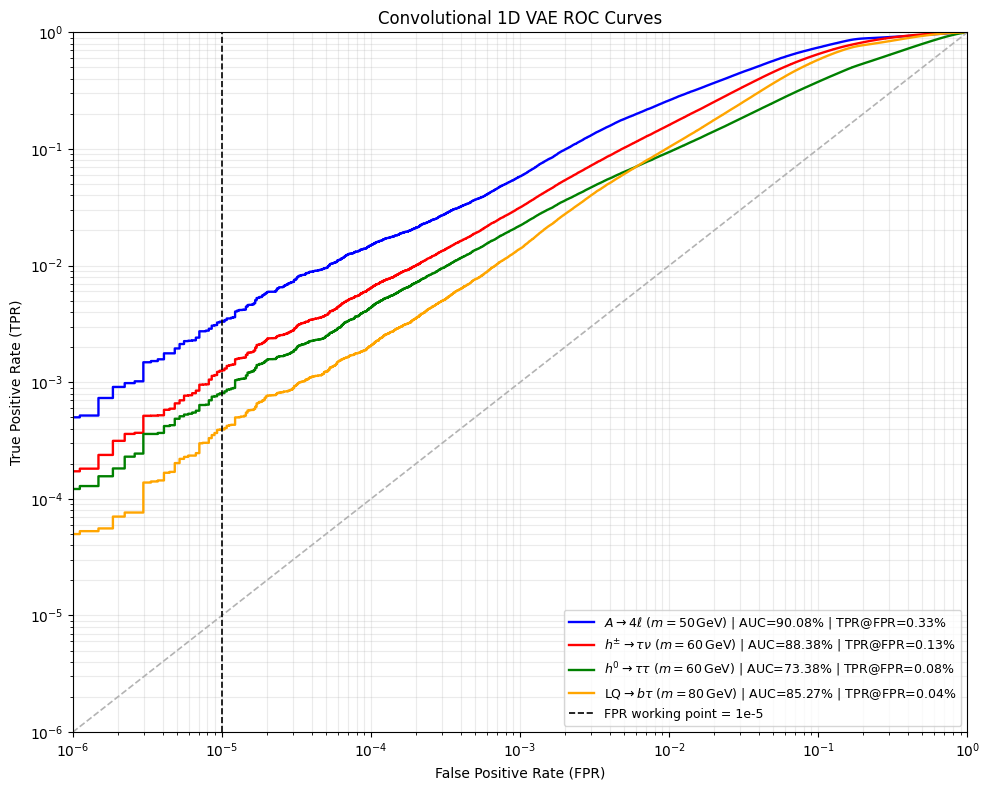

In [14]:
sample_colors = {
    "background": "black",
    "Ato4l": "blue",
    "hChToTauNu": "red",
    "hToTauTau": "green",
    "leptoquark": "orange",
}

signal_labels = {
    "Ato4l": r"$A \rightarrow 4\ell$ ($m = 50\,\mathrm{GeV}$)",
    "hChToTauNu": r"$h^{\pm} \rightarrow \tau \nu$ ($m = 60\,\mathrm{GeV}$)",
    "hToTauTau": r"$h^0 \rightarrow \tau \tau$ ($m = 60\,\mathrm{GeV}$)",
    "leptoquark": r"$\mathrm{LQ} \rightarrow b \tau$ ($m = 80\,\mathrm{GeV}$)",
}

plt.figure(figsize=(10, 8))
for name in SIGNAL_FILES.keys():
    rc = roc_curves[name]
    plt.plot(
        rc['fpr'],
        rc['tpr'],
        linewidth=1.7,
        color=sample_colors[name],
        label=f"{signal_labels[name]} | AUC={rc['auc']*100:.2f}% | TPR@FPR={rc['tpr_at_threshold']*100:.2f}%"
    )

plt.plot([1e-6, 1.0], [1e-6, 1.0], "--", color="0.70", linewidth=1.2)
plt.axvline(FPR_THRESHOLD, color="black", linestyle="--", linewidth=1.2, label="FPR working point = 1e-5")
plt.xscale("log")
plt.yscale("log")
plt.xlim(1e-6, 1.0)
plt.ylim(1e-6, 1.0)
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("Convolutional 1D VAE ROC Curves")
plt.grid(True, which="both", alpha=0.25)
plt.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

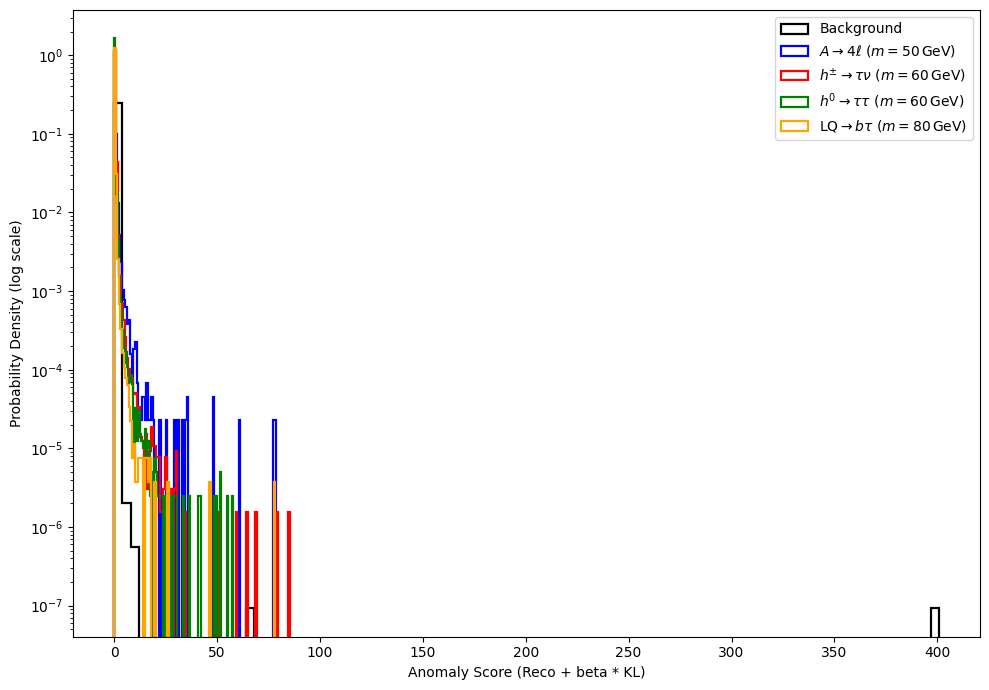

In [16]:
plt.figure(figsize=(10, 7))

plt.hist(
    bkg_scores,
    bins=100,
    density=True,
    histtype="step",
    linewidth=1.6,
    label="Background",
    color=sample_colors["background"]
)

for name in SIGNAL_FILES.keys():
    plt.hist(
        signal_scores[name],
        bins=100,
        density=True,
        histtype="step",
        linewidth=1.6,
        label=signal_labels[name],
        color=sample_colors[name]
    )

plt.yscale("log")
plt.xlabel("Anomaly Score (Reco + beta * KL)")
plt.ylabel("Probability Density (log scale)")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

In [18]:
out_dir = Path("../results/convolutional_VAE") / MODEL_NAME
out_dir.mkdir(parents=True, exist_ok=True)

PNG_DPI = 300

signal_names = list(signal_scores.keys())

# -------------------------
# SCORE DISTRIBUTIONS
# -------------------------
fig_scores = plt.figure(figsize=(10, 7))

plt.hist(
    bkg_scores,
    bins=100,
    density=True,
    histtype="step",
    linewidth=1.6,
    label="Background",
    color=sample_colors["background"],
)

for name in signal_names:
    plt.hist(
        signal_scores[name],
        bins=100,
        density=True,
        histtype="step",
        linewidth=1.6,
        label=name,
        color=sample_colors[name],
    )

plt.yscale("log")
plt.xlabel("Anomaly Score (Reco + beta * KL)")
plt.ylabel("Probability Density (log scale)")
plt.legend(loc="upper right")
plt.tight_layout()

fig_scores.savefig(out_dir / "scores.png", dpi=PNG_DPI, bbox_inches="tight")
plt.close(fig_scores)

# -------------------------
# ROC CURVES
# -------------------------
fig_roc = plt.figure(figsize=(10, 8))

for name in signal_names:
    rc = roc_curves[name]

    plt.plot(
        rc["fpr"],
        rc["tpr"],
        linewidth=1.7,
        color=sample_colors[name],
        label=f"{name} | AUC={rc['auc']*100:.2f}%",
    )

plt.plot([1e-6, 1.0], [1e-6, 1.0], "--", color="0.70", linewidth=1.2)
plt.axvline(
    FPR_THRESHOLD,
    color="blue",
    linestyle="--",
    linewidth=1.2,
    label="FPR working point = 1e-5",
)

plt.xscale("log")
plt.yscale("log")
plt.xlim(1e-6, 1.0)
plt.ylim(1e-6, 1.0)

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("Convolutional 1D VAE ROC Curves")

plt.grid(True, which="both", alpha=0.25)
plt.legend(loc="lower right", fontsize=9)
plt.tight_layout()

fig_roc.savefig(out_dir / "roc.png", dpi=PNG_DPI, bbox_inches="tight")
plt.close(fig_roc)

# -------------------------
# SAVE SCORES
# -------------------------
scores_payload = {
    "bkg_total": bkg_scores.astype(np.float32),
}

for name in signal_names:
    scores_payload[f"{name}_total"] = signal_scores[name].astype(np.float32)

np.savez_compressed(out_dir / "scores.npz", **scores_payload)

# -------------------------
# SAVE ROC DATA
# -------------------------
roc_payload = {}

for name in signal_names:
    rc = roc_curves[name]

    roc_payload[f"fpr_{name}"] = rc["fpr"].astype(np.float32)
    roc_payload[f"tpr_{name}"] = rc["tpr"].astype(np.float32)
    roc_payload[f"thresholds_{name}"] = rc["thr"].astype(np.float32)
    roc_payload[f"auc_{name}"] = np.array([rc["auc"]], dtype=np.float64)
    roc_payload[f"tpr_at_fpr_1e5_{name}"] = np.array(
        [rc["tpr_at_threshold"]], dtype=np.float64
    )

np.savez_compressed(out_dir / "roc_data.npz", **roc_payload)

# -------------------------
# METRICS
# -------------------------
df_metrics.to_csv(out_dir / "metrics.csv")

print(f"Export completed: {out_dir}")
print("Saved files:")
for name in ["metrics.csv", "roc.png", "scores.png", "roc_data.npz", "scores.npz"]:
    print(" -", name)

Export completed: ../results/convolutional_VAE/conv1d_vae_0
Saved files:
 - metrics.csv
 - roc.png
 - scores.png
 - roc_data.npz
 - scores.npz
